In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile
import os
import yaml
from skimage.draw import polygon
from skimage.metrics import structural_similarity

In [2]:
with open(r'C:\Users\lmcke\PycharmProjects\yolo_fires\final_pipeline\master_test.yaml', 'r') as file:
    data = yaml.safe_load(file)

tile_size= data['tile_size']
step_size= data['step_size']

test_images = data['test_images']

test_masks = data['test_masks']

channels = data['channels']

# image folder where fires are visible (tif files)
images_path = r"C:\Users\lmcke\Documents\JPL\results\new_config_3_2\images"

# folder with ground truth label mask pngs
png_gt_dir = r"C:\Users\lmcke\Documents\JPL\input_tiles\dataInput\pngTiles\test"

# folder with predicted labels
results_dir = r"C:\Users\lmcke\Documents\JPL\results\new_config_3_2\labels"

In [3]:
def IoU(gt, res):
    intersection = np.sum((gt & res))
    union = np.sum((gt | res))
    if union == 0:
        return np.nan
    return intersection / union

def Dice(gt, res):
    intersection = np.sum((gt & res))
    if (np.sum(gt) + np.sum(res)) == 0:
        return np.nan
    return (2*intersection) / (np.sum(gt) + np.sum(res))

def precision(gt, res):
    tru_pos = (gt & res).sum()
    fal_pos = ((res==True) & (gt==False)).sum()
    if (tru_pos+fal_pos) == 0:
        return np.nan
    return tru_pos/(tru_pos+fal_pos)

def recall(gt, res):
    tru_pos = (gt & res).sum()
    fal_neg = ((res==False) & (gt==True)).sum()
    if (tru_pos+fal_neg) == 0:
        return np.nan
    return tru_pos/(tru_pos+fal_neg)

In [4]:
result_png_dir = os.path.join(results_dir, "result_pngs")
os.makedirs(result_png_dir , exist_ok=True)

GT_masks = []
result_masks = []
IoU_all = []
dice_all = []
prec_all = []
rec_all = []
for file in os.listdir(png_gt_dir):
    filepath = os.path.join(png_gt_dir, file)
    path, filename = os.path.split(filepath)
    name, ext = os.path.splitext(filename)
    print(name)

    gt_mask = np.squeeze(cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)).astype(float)
    GT_masks.append(gt_mask.copy())

    im_file = os.path.join(images_path, name+'.tif')
    image = tifffile.imread(im_file)

    txt_path = os.path.join(results_dir, f'{name}.txt')
    tile = np.zeros((tile_size, tile_size))
    if os.path.exists(txt_path):
        print('labels detected')
        txt_file = open(txt_path)
        labels = txt_file.readlines()

        for row in range(len(labels)):
            label = labels[row].split()
            class_ = label[0]
            conf = label[-1]
            print(conf)
            coords = list(map(float, label[1:-1]))
            if len(coords) != 0:
                polygon_coords = []
                for i in range(0, len(coords), 2):
                    polygon_coords.append([round(coords[i]*(tile_size)), round(coords[i+1]*(tile_size))])
                polygon_coords = np.array(polygon_coords)
                print(np.shape(polygon_coords))
                row, col = polygon(polygon_coords[:,1], polygon_coords[:,0], shape=(tile_size, tile_size))
                tile[row, col] = 2

    result_masks.append(tile.copy())
    gt = gt_mask.astype(bool)
    res = tile.copy().astype(bool)
    iou = IoU(gt, res)
    dice = Dice(gt, res)
    prec = precision(gt, res)
    rec = recall(gt, res)

    IoU_all.append(iou)
    dice_all.append(dice)
    prec_all.append(prec)
    rec_all.append(rec)

    res_mask = tile + gt_mask
    # 0 = nothing
    # 1 = false negative
    # 2 = false positive
    # 3 = true positive

    res_mask[res_mask==0] = np.nan

    tile[tile==2]=1
    mssim, ssim = structural_similarity(tile, gt_mask, data_range=1, full=True, win_size=tile_size-1)

    plt.figure(dpi=200)
    plt.imshow(image[:,:,0], vmin=0, vmax=255, cmap='gray')
    plt.imshow(res_mask, vmin=1, vmax=3, cmap='cool', alpha=0.5)
    plt.colorbar()
    plt.text(5, 15, f'SSIM = {np.round(mssim, 2)}', color='white', fontsize=20)
    plt.text(5, 30, f'P = {np.round(prec, 2)}', color='white', fontsize=20)
    plt.text(5, 45, f'R = {np.round(rec, 2)}', color='white', fontsize=20)
    plt.axis('off')
    plt.savefig(os.path.join(result_png_dir, name+'.png'), bbox_inches='tight', transparent=True)
    plt.close()


MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_0
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_1
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_10
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_11
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_12
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_13
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_14
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_15
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_16
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_17
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_18
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_19
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_2
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_20
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_21
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_22
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_23
MASTERL1B_1981719_08_20190806_2249_2259_V01.fire_0_24
MASTERL1B_1981719_08_20190806_2

In [5]:
gt_all = np.array(GT_masks).astype(bool)
result_all = np.array(result_masks).astype(bool)

IoU_overall = IoU(gt_all, result_all)
dice_overall = Dice(gt_all, result_all)
prec_overall = precision(gt_all, result_all)
rec_overall = recall(gt_all, result_all)
mssim_overall = structural_similarity(result_all.astype(int), gt_all.astype(int), data_range=1, win_size=tile_size-1)

print('Overall IoU =', IoU_overall)
print('Overall Dice Indx =', dice_overall)
print('Overall Precision =', prec_overall)
print('Overall Recall =', rec_overall)
print('Overall MSSIM =', mssim_overall)

Overall IoU = 0.7564715589653705
Overall Dice Indx = 0.8613536098597139
Overall Precision = 0.8364595611569499
Overall Recall = 0.887774864071597
Overall MSSIM = 0.9291721152148966


In [6]:
# combine detected tiles into original image size

pred_labels_all = []
for file in test_images:
    path, filename = os.path.split(file)
    name, ext = os.path.splitext(filename)
    print(name)

    image = tifffile.imread(file)
    ydim, xdim = np.shape(image[:,:,channels[-1]])

    untiled_y = ydim % tile_size
    pad_y = tile_size - untiled_y
    untiled_x = xdim % tile_size
    pad_x = tile_size - untiled_x

    img_mask = np.zeros((ydim+pad_y,xdim+pad_x))
    for label in os.listdir(results_dir):
        if label.startswith(name):
            name, tile, txt_ext = label.split(".")
            fire, row, col = tile.split("_")
            row = int(row)
            col = int(col)
            print(row, col)
            txt_path = os.path.join(results_dir, label)

            txt_file = open(txt_path)
            labels = txt_file.readlines()

            tile = np.zeros((tile_size, tile_size))
            for label_row in range(len(labels)):
                label = labels[label_row].split()
                class_ = label[0]
                conf = label[-1]
                coords = list(map(float, label[1:-1]))
                if len(coords) != 0:
                    polygon_coords = []
                    for i in range(0, len(coords), 2):
                        polygon_coords.append([int(coords[i]*(tile_size)), int(coords[i+1]*(tile_size))])
                    polygon_coords = np.array(polygon_coords)
                    tile_row, tile_col = polygon(polygon_coords[:,1], polygon_coords[:,0])
                    tile[tile_row, tile_col] = 1

            img_mask[int((row+1)*step_size-0.5*tile_size):int((row+1)*step_size+0.5*tile_size), int((col+1)*step_size-0.5*tile_size):int((col+1)*step_size+0.5*tile_size)] += tile

    pred_labels_all.append(img_mask[:-1*pad_y, :-1*pad_x].astype(bool))


MASTERL1B_1981719_08_20190806_2249_2259_V01
0 3
0 4
0 5
0 6
1 3
1 4
1 5
1 6
1 7
2 3
2 4
2 5
2 6
2 7
MASTERL1B_1981720_09_20190808_0237_0238_V01
1 2
1 3
1 4
1 5
1 6
1 7
1 8
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
4 10
4 5
4 6
4 7
4 8
4 9
5 10
5 5
5 6
5 7
5 8
5 9
6 10
6 5
6 6
6 7
6 8
6 9
MASTERL1B_1981725_01_20190817_0004_0007_V01
5 4
5 5
6 3
6 4
6 5
7 3
7 4
7 5
8 3
8 4
8 5
MASTERL1B_1981725_02_20190817_0025_0026_V01
3 2
3 3
3 4
3 5
4 2
4 3
4 4
4 5
5 2
5 3
5 4
5 5


In [7]:
# creating difference maps

diff_map_all = []
res_mask_all = []
gt_mask_all = []
ssim_all = []
prec_all = []
rec_all = []
for i, label_file in enumerate(test_masks):

    gt_mask = tifffile.imread(label_file)
    gt_mask_all.append(gt_mask)

    pred_mask = pred_labels_all[i].astype(int)
    print(np.shape(pred_mask))

    img_50 = tifffile.imread(test_images[i])
    invalid_mask = img_50[:,:,0]!=-9999.0
    #print(np.shape(invalid_mask))

    mssim, ssim = structural_similarity(pred_mask[invalid_mask], gt_mask[invalid_mask], data_range=1, full=True, win_size=min(np.shape(gt_mask))-1)
    print(mssim)
    ssim_all.append(mssim)

    prec = precision(gt_mask[invalid_mask], pred_mask[invalid_mask])
    prec_all.append(prec)
    rec = recall(gt_mask[invalid_mask], pred_mask[invalid_mask])
    rec_all.append(rec)

    diff_map = pred_mask-gt_mask
    diff_map_all.append(diff_map)

    pred_mask[pred_mask==1]=2
    res_mask = pred_mask+gt_mask
    res_mask_all.append(res_mask)

print('Average SSIM:', np.mean(ssim_all))

(978, 5118)
0.9882029774313579
(590, 1065)
0.8639421837145701
(898, 1523)
0.9303124832981374
(538, 634)
0.9253922296550913
Average SSIM: 0.9269624685247891


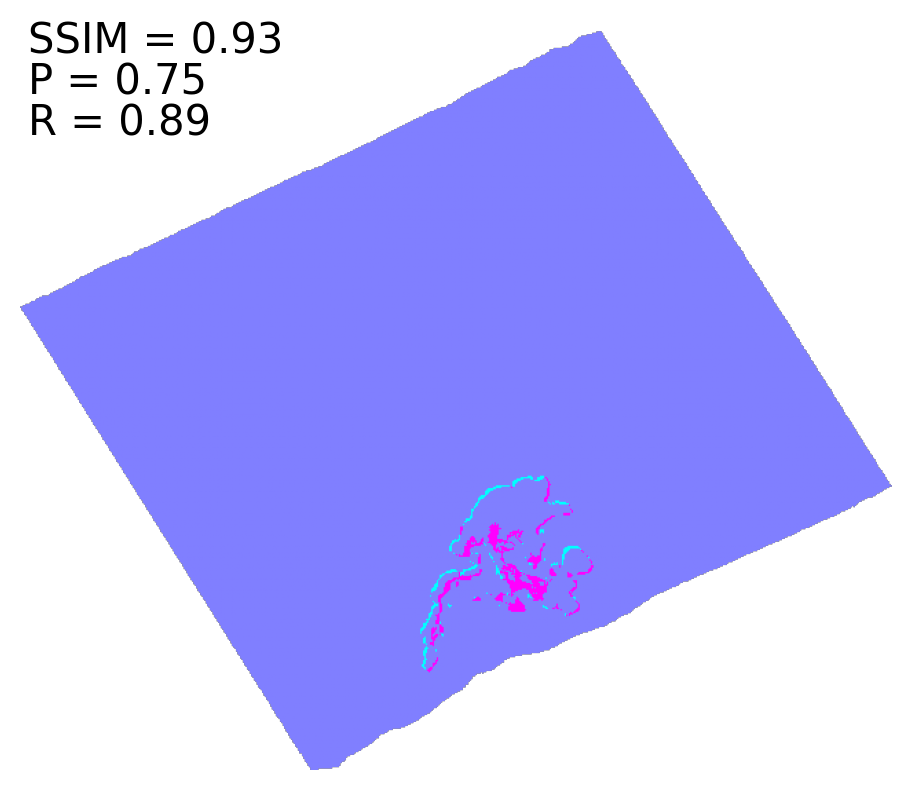

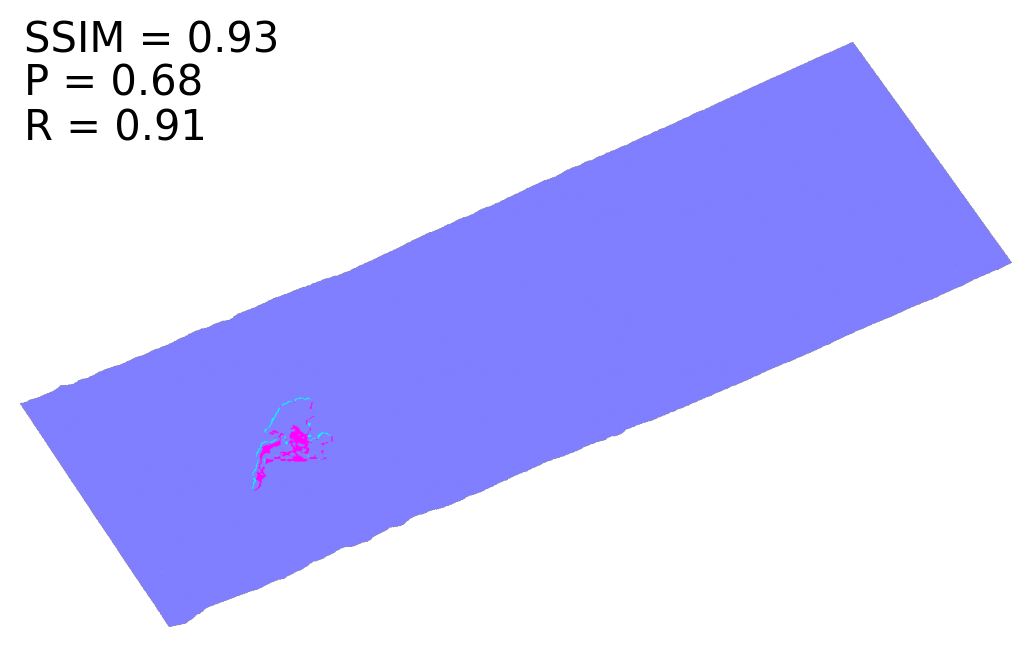

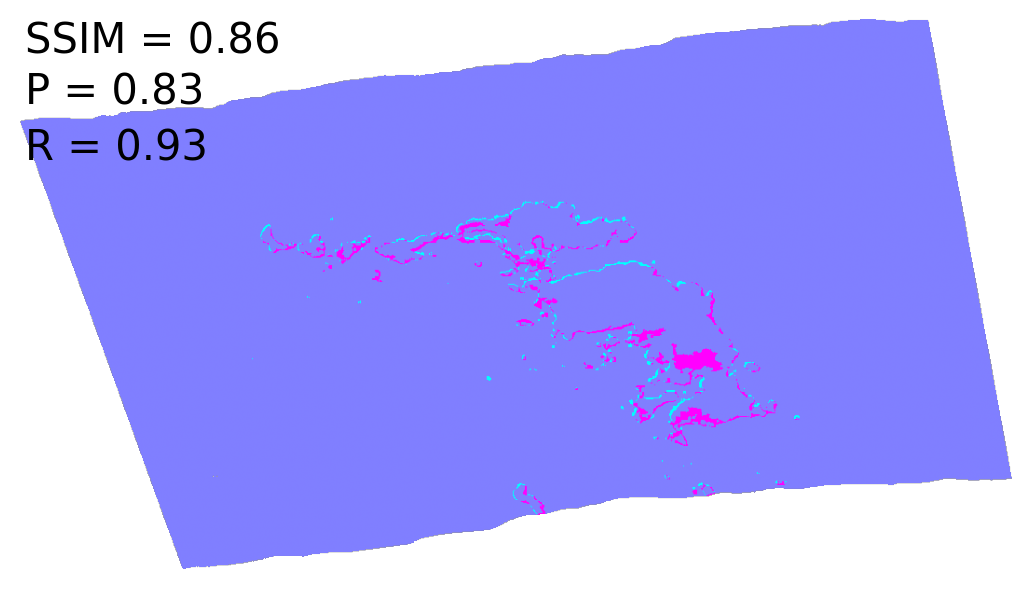

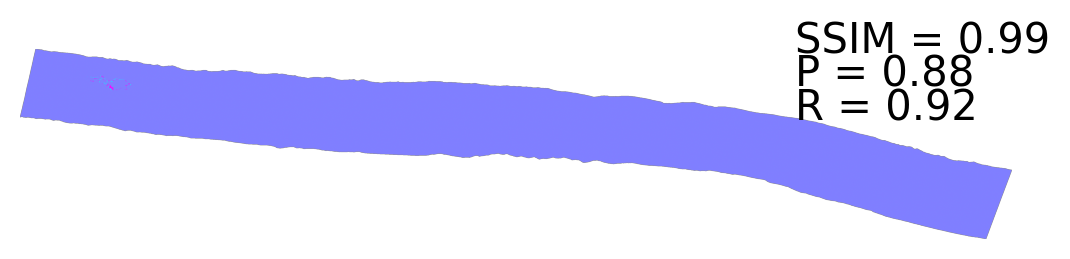

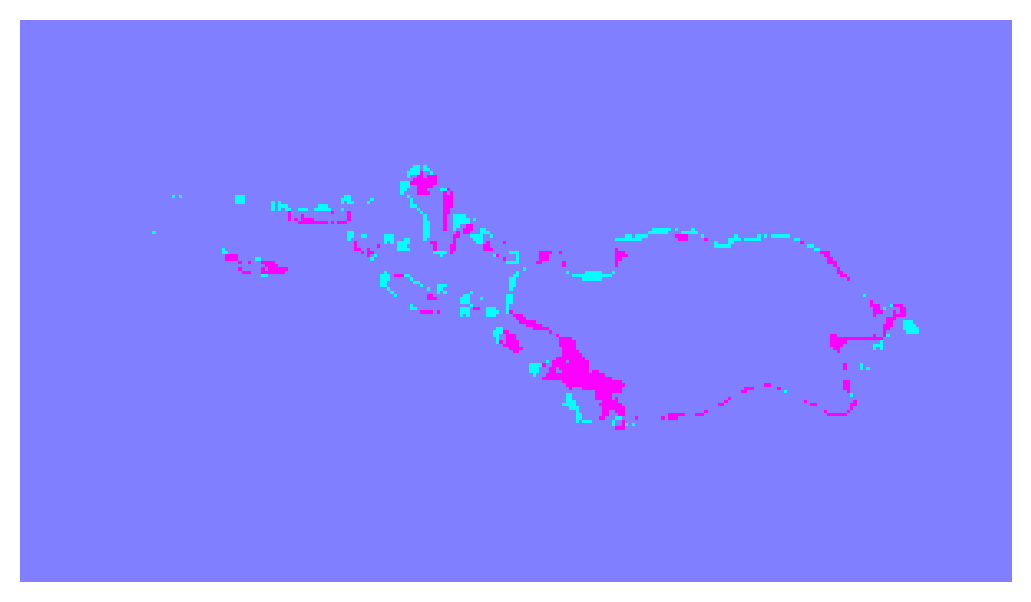

In [8]:
diffmap = diff_map_all[3].astype(float)
img_50 = tifffile.imread(test_images[3])
invalid_mask = img_50[:,:,0]!=-9999.0
#invalid_mask = invalid_mask[300:500,250:450]
diffmap[~invalid_mask] = np.nan
plt.figure(dpi=200)
plt.imshow(diffmap, cmap='cool', interpolation=None)
plt.text(5, 15, f'SSIM = {np.round(ssim_all[3], 2)}', color='black', fontsize=15)
plt.text(5, 45, f'P = {np.round(prec_all[3], 2)}', color='black', fontsize=15)
plt.text(5, 75, f'R = {np.round(rec_all[3], 2)}', color='black', fontsize=15)
plt.axis('off')
#plt.colorbar()
plt.savefig(os.path.join(results_dir, '3.png'), bbox_inches='tight', transparent=True)
plt.show()

diffmap = diff_map_all[2].astype(float)
img_50 = tifffile.imread(test_images[2])
invalid_mask = img_50[:,:,0]!=-9999.0
#invalid_mask = invalid_mask[400:800,200:600]
diffmap[~invalid_mask] = np.nan
plt.figure(dpi=200)
plt.imshow(diffmap, cmap='cool', interpolation=None)
plt.text(5, 15, f'SSIM = {np.round(ssim_all[2], 2)}', color='black', fontsize=15)
plt.text(5, 80, f'P = {np.round(prec_all[2], 2)}', color='black', fontsize=15)
plt.text(5, 150, f'R = {np.round(rec_all[2], 2)}', color='black', fontsize=15)
plt.axis('off')
#plt.colorbar()
plt.savefig(os.path.join(results_dir, '2.png'), bbox_inches='tight', transparent=True)
plt.show()

diffmap = diff_map_all[1].astype(float)
img_50 = tifffile.imread(test_images[1])
invalid_mask = img_50[:,:,0]!=-9999.0
diffmap[~invalid_mask] = np.nan
plt.figure(dpi=200)
# diff_map_all[1][240:400,560:720],
plt.imshow(diffmap, cmap='cool', interpolation=None)
plt.text(5, 35, f'SSIM = {np.round(ssim_all[1], 2)}', color='black', fontsize=15)
plt.text(5, 90, f'P = {np.round(prec_all[1], 2)}', color='black', fontsize=15)
plt.text(5, 150, f'R = {np.round(rec_all[1], 2)}', color='black', fontsize=15)
plt.axis('off')
#plt.colorbar()
plt.savefig(os.path.join(results_dir, '1.png'), bbox_inches='tight', transparent=True)
plt.show()

diffmap = diff_map_all[0].astype(float)
img_50 = tifffile.imread(test_images[0])
invalid_mask = img_50[:,:,0]!=-9999.0
#invalid_mask = invalid_mask[90:260,300:600]
diffmap[~invalid_mask] = np.nan
plt.figure(dpi=200)
# diff_map_all[0][90:260,300:600]
plt.imshow(diffmap, cmap='cool', interpolation=None)
plt.text(4000, 15, f'SSIM = {np.round(ssim_all[0], 2)}', color='black', fontsize=15)
plt.text(4000, 190, f'P = {np.round(prec_all[0], 2)}', color='black', fontsize=15)
plt.text(4000, 365, f'R = {np.round(rec_all[0], 2)}', color='black', fontsize=15)
plt.axis('off')
#plt.colorbar()
plt.savefig(os.path.join(results_dir, '0.png'), bbox_inches='tight', transparent=True)
plt.show()

diffmap = diff_map_all[0][90:260,300:600].astype(float)
img_50 = tifffile.imread(test_images[0])
invalid_mask = img_50[:,:,0]!=-9999.0
invalid_mask = invalid_mask[90:260,300:600]
diffmap[~invalid_mask] = np.nan
plt.figure(dpi=200)
# diff_map_all[0][90:260,300:600]
plt.imshow(diffmap, cmap='cool', interpolation=None)
plt.axis('off')
#plt.colorbar()
plt.savefig(os.path.join(results_dir, '0.png'), bbox_inches='tight', transparent=True)
plt.show()

In [9]:
print(np.mean(ssim_all))
print(np.mean(prec_all))
print(np.mean(rec_all))

0.9269624685247891
0.7867308179877679
0.9111796918726534
